# Task 1 — Data Loading, Merging & Deep Exploration


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [ ]:
#  Load the Superstore Sales CSV using Pandas
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
 # Parse the Order Date and Ship Date columns as proper datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
# Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [ ]:
# create season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"
df["Season"] = df["Month"].apply(get_season)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [ ]:
# Check for missing values, duplicates, and data type issues
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

In [ ]:
df.isnull().sum().sum()

np.int64(11)

In [ ]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,...,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,2017,5,May,20,Sunday,2,Spring
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,2016,1,January,2,Tuesday,1,Winter
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,Phones,GE 30524EE4,235.1880,2016,1,January,2,Tuesday,1,Winter
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,2016,1,January,2,Tuesday,1,Winter


In [ ]:
# Check Data Types
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Week Number              UInt32
Day of Week              object
Quarter                   int32
Season                   object
dtype: object

In [ ]:
# Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
# Daily Sales
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [ ]:
# Weekly Sales
weekly_sales = (daily_sales.set_index("Order Date").resample("W")["Sales"].sum().reset_index())
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
# Monthly Sales
monthly_sales = (daily_sales.set_index("Order Date").resample("M")["Sales"].sum().reset_index())
monthly_sales.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\636614903.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = (daily_sales.set_index("Order Date").resample("M")["Sales"].sum().reset_index())


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
#Which product category generates the highest total revenue?
categ_sales = (df.groupby("Category")["Sales"].sum().sort_values(ascending=False))
print(categ_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


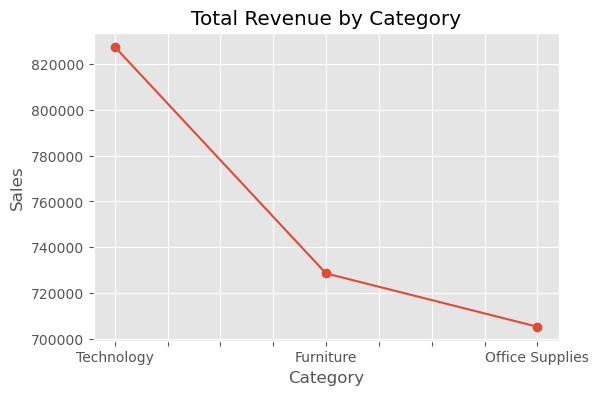

In [ ]:
categ_sales.plot(figsize=(6,4),marker="o")
plt.title("Total Revenue by Category")
plt.ylabel("Sales")
plt.show()

In [ ]:
# Which region has the most consistent sales growth over 4 years?
region_year_sales = (df.groupby(["Year","Region"])["Sales"].sum().reset_index())
print(region_year_sales)

    Year   Region        Sales
0   2015  Central  102920.5206
1   2015     East  127652.8190
2   2015    South  103374.9055
3   2015     West  145907.9630
4   2016  Central  102425.1724
5   2016     East  153225.1830
6   2016    South   70076.0825
7   2016     West  133709.5675
8   2017  Central  145673.8800
9   2017     East  178511.5380
10  2017    South   93535.9035
11  2017     West  182471.2285
12  2018  Central  141627.3402
13  2018     East  210129.1860
14  2018    South  122164.5675
15  2018     West  248130.9255


In [ ]:
pivot = region_year_sales.pivot(index="Year",columns="Region",values="Sales")
pivot

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


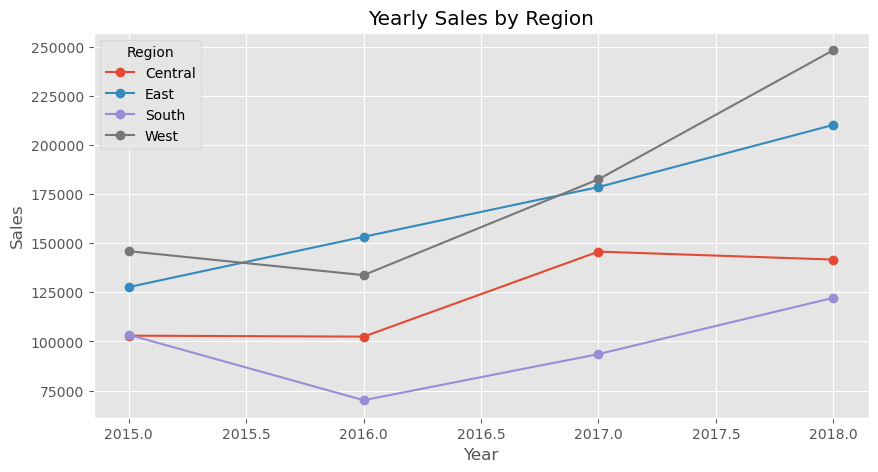

In [ ]:
pivot.plot(figsize=(10,5), marker="o")
plt.title("Yearly Sales by Region")
plt.ylabel("Sales")
plt.show()

In [ ]:
growth_var = pivot.pct_change().std()
print(growth_var)

Region
Central    0.253453
East       0.017939
South      0.371249
West       0.257431
dtype: float64


In [ ]:
# What is the average time between Order Date and Ship Date — and does it vary by region?
df["Shipping Days"] = (df["Ship Date"] -df["Order Date"]).dt.days
avg_shipping = df["Shipping Days"].mean()
print(avg_shipping)

3.9611224489795918


In [ ]:
shipping_region = (df.groupby("Region")["Shipping Days"].mean().sort_values())
print(shipping_region)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


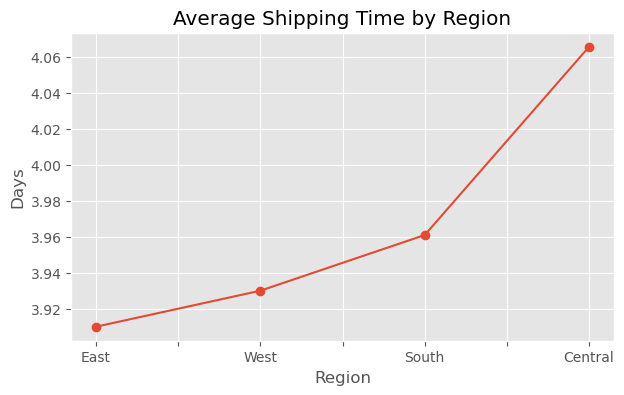

In [ ]:
shipping_region.plot(figsize=(7,4),marker="o")
plt.title("Average Shipping Time by Region")
plt.ylabel("Days")
plt.show()

In [ ]:
# Are there months that consistently spike across all years (seasonality)?
monthly = (df.groupby(["Year","Month"])["Sales"].sum().reset_index())
print(monthly)

    Year  Month        Sales
0   2015      1   14205.7070
1   2015      2    4519.8920
2   2015      3   55205.7970
3   2015      4   27906.8550
4   2015      5   23644.3030
5   2015      6   34322.9356
6   2015      7   33781.5430
7   2015      8   27117.5365
8   2015      9   81623.5268
9   2015     10   31453.3930
10  2015     11   77907.6607
11  2015     12   68167.0585
12  2016      1   18066.9576
13  2016      2   11951.4110
14  2016      3   32339.3184
15  2016      4   34154.4685
16  2016      5   29959.5305
17  2016      6   23599.3740
18  2016      7   28608.2590
19  2016      8   36818.3422
20  2016      9   63133.6060
21  2016     10   31011.7375
22  2016     11   75249.3995
23  2016     12   74543.6012
24  2017      1   18542.4910
25  2017      2   22978.8150
26  2017      3   51165.0590
27  2017      4   38679.7670
28  2017      5   56656.9080
29  2017      6   39724.4860
30  2017      7   38320.7830
31  2017      8   30542.2003
32  2017      9   69193.3909
33  2017     1

In [ ]:
pivot = monthly.pivot(index="Year",columns="Month",values="Sales")
pivot

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,75249.3995,74543.6012
2017,18542.4910,22978.8150,51165.0590,38679.7670,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,43476.4740,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,83030.3888


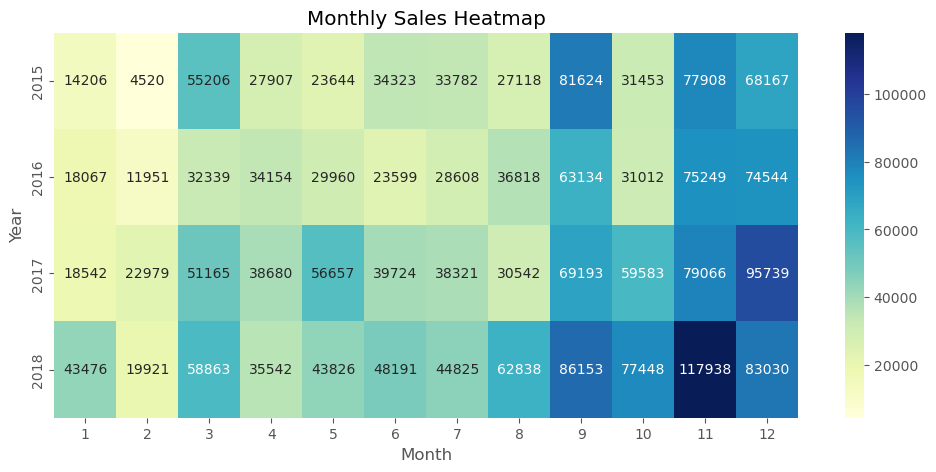

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(pivot,annot=True,fmt=".0f",cmap="YlGnBu")
plt.title("Monthly Sales Heatmap")
plt.show()

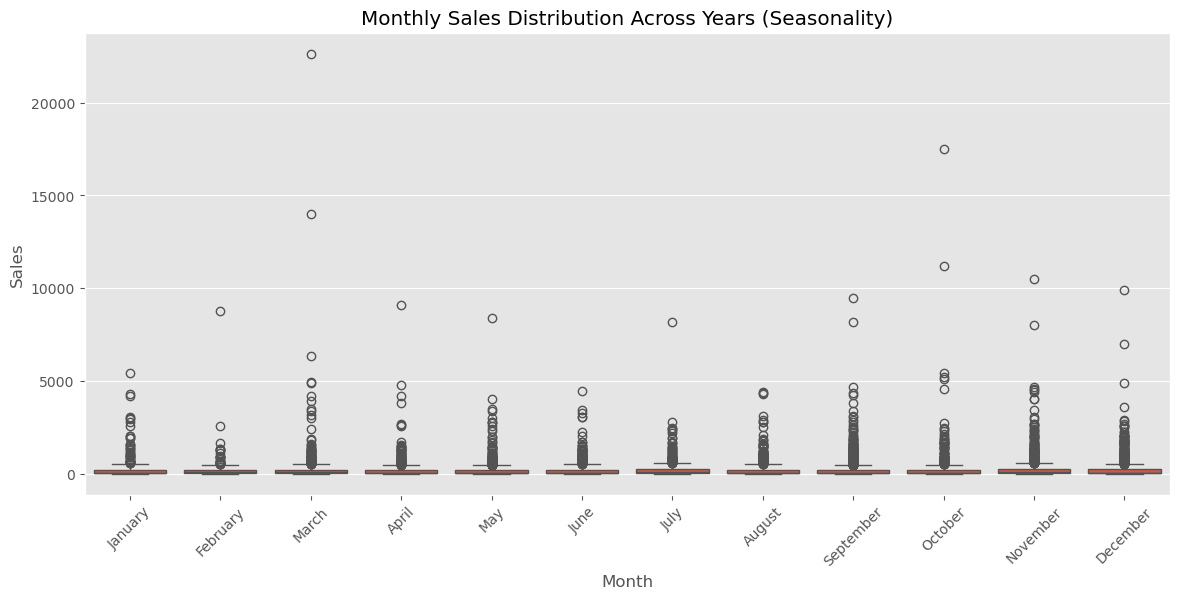

In [ ]:
#BoxPlot the Seasonality
month_order = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]
plt.figure(figsize=(14,6))
sns.boxplot(data=df,x="Month Name",y="Sales",order=month_order)
plt.xticks(rotation=45)
plt.title("Monthly Sales Distribution Across Years (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [ ]:
# Find the Average Sales for Each Month
avg_month_sales = monthly.mean()
avg_month_sales = avg_month_sales.sort_values(ascending=False)
print(avg_month_sales)

Sales    47115.34964
Year      2016.50000
Month        6.50000
dtype: float64


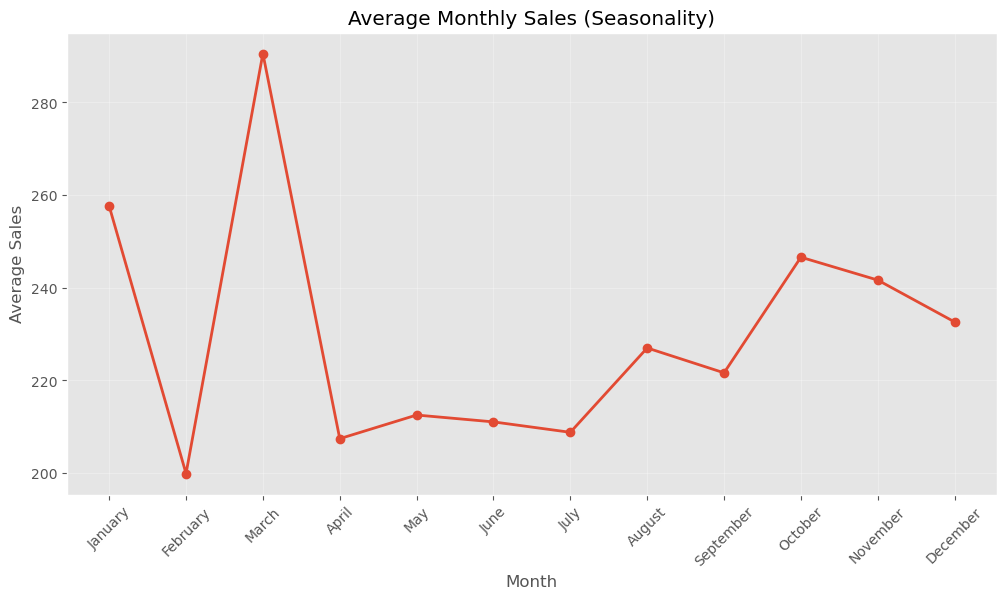

In [ ]:
# Plot the average sales per month:
monthly_avg = (df.groupby("Month Name")["Sales"].mean().reindex(month_order))
plt.figure(figsize=(12,6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
plt.title("Average Monthly Sales (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# Task 2 — Time Series Analysis & Decomposition

In [ ]:
# Plot the overall monthly sales trend across all 4 years
monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum())
monthly_sales.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\2555812675.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum())


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

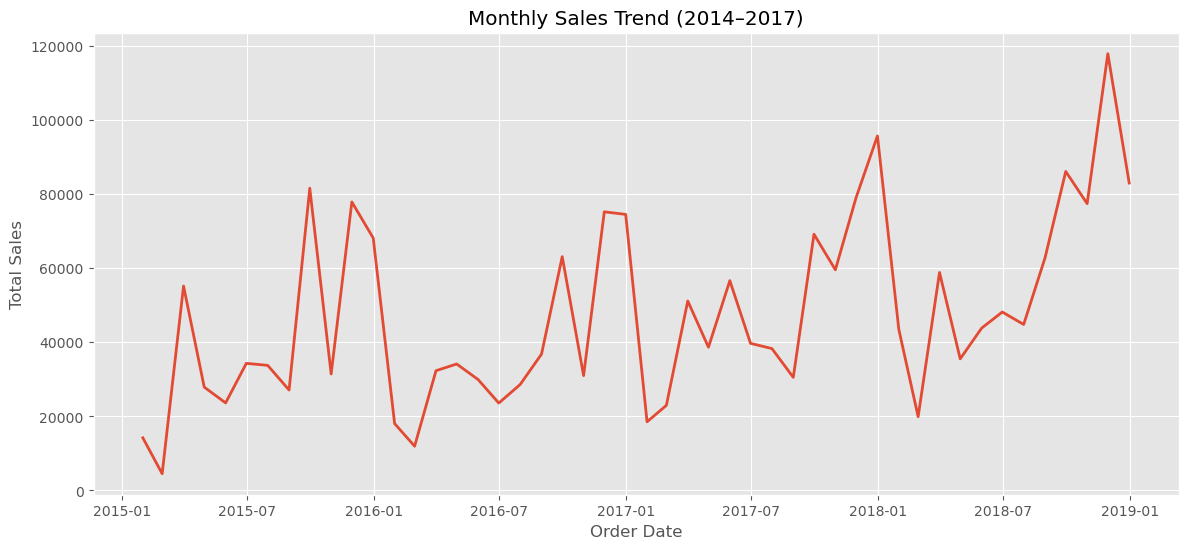

In [ ]:
# Plot Overall Monthly Sales Trend
plt.figure(figsize=(14,6))
plt.plot(monthly_sales, linewidth=2)
plt.title("Monthly Sales Trend (2014–2017)")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

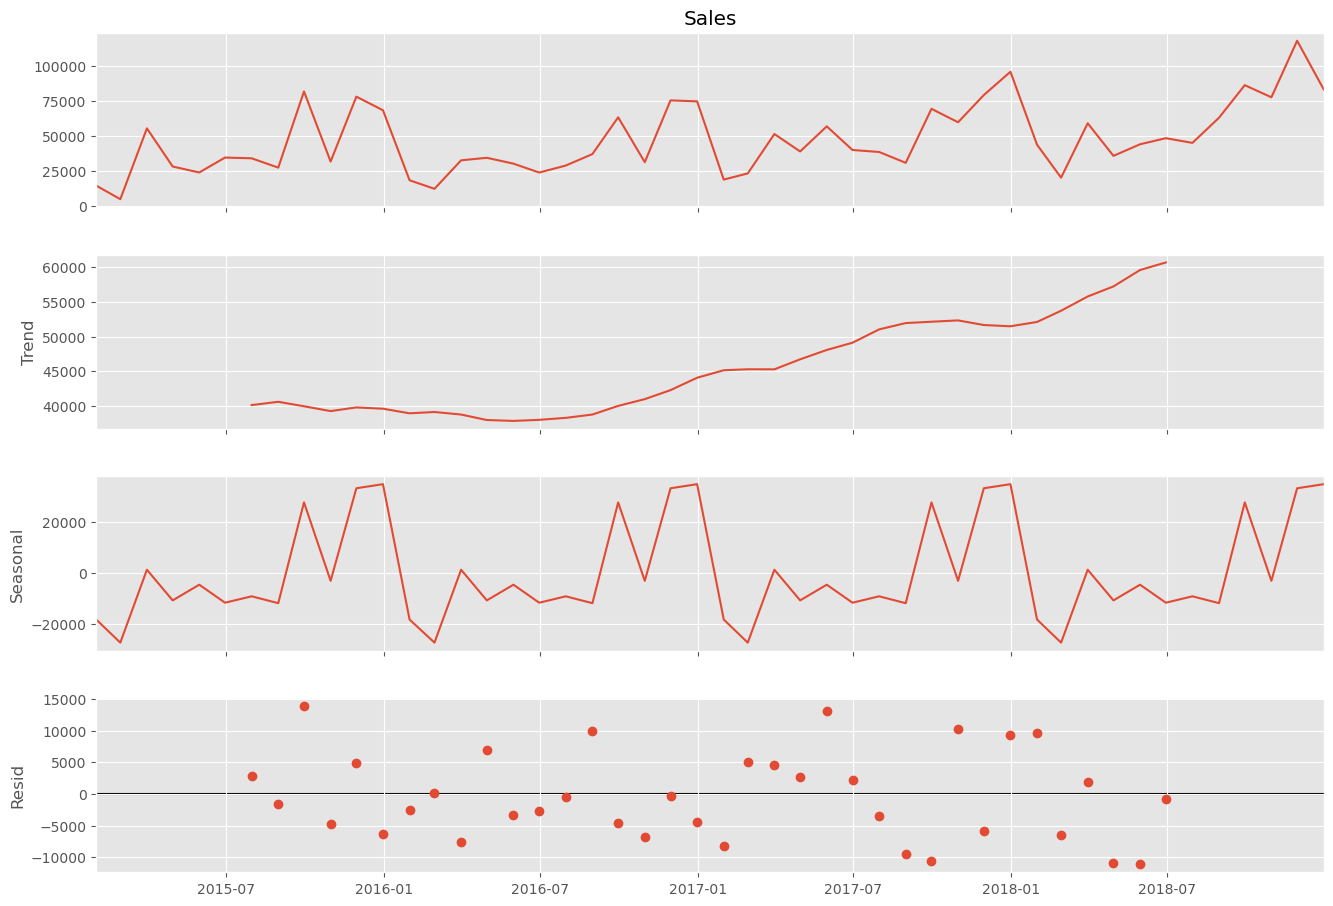

In [ ]:
# Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(monthly_sales,model="additive",period=12)
fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

# Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?


In [ ]:
# Observation 1: Trend Component
# The trend component shows an overall upward trend in monthly sales over the four-year period.
# Sales remain relatively stable during the early months (around 38,000–40,000) and then gradually increase, reaching over 60,000 by the end of the period.
# This indicates sustained business growth over time.

In [ ]:
# Observation 2: Seasonal Component
# The seasonal component exhibits a strong and consistent repeating pattern every 12 months.
# The same months experience higher and lower sales each year, confirming the presence of strong seasonality.
# This suggests that customer demand follows a predictable annual cycle, making seasonality an important factor for forecasting.

In [ ]:
# Observation 3: Residual (Noise) Component
# The residual component is centered around zero, indicating that the decomposition has successfully captured most of the trend and seasonal effects.
# However, a few months show large positive residuals (around +13,000 to +14,000) and large negative residuals (around -10,000 to -11,000).
# These months represent unusual sales fluctuations that cannot be explained by normal trend or seasonal behavior and may be due to promotions, discounts, or unexpected market events.

In [ ]:
# Observation 4: Overall Interpretation
# Overall, the decomposition indicates that monthly sales are driven by both a positive long-term trend and strong seasonal patterns.
# Since most residual values are relatively small and randomly distributed around zero, the decomposition effectively explains the underlying sales behavior.
# This suggests that the data is well-suited for time-series forecasting models such as Holt-Winters, SARIMA, or Prophet, which can capture both trend and seasonality.

# Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(monthly_sales)
print("ADF Statistic :", result[0])
print("p-value :", result[1])
for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430768
p-value : 0.00027791039276670677
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [ ]:
# Interpretation
# The series is stationary because the p-value is less than 0.05.

In [ ]:
# What is Stationarity?
# Stationarity means that the statistical properties of a time series, such as its average (mean) and variability (variance), remain relatively constant over time.
# In a stationary series, there are no strong long-term changes in the overall pattern, making it easier to analyze changes in the data.

# According to Your ADF Test Result
# The ADF test was used to check whether the monthly sales data is stationary.
# The obtained p-value is 0.000278, which is less than 0.05. Therefore, we reject the null hypothesis and conclude that the monthly sales series is stationary.
# This means the sales data has a stable statistical pattern over time and does not require differencing before further time series analysis.

In [ ]:
# Apply differencing if the series is non-stationary and re-test
# Mention that differencing is not required
# because The original monthly sales series was already stationary because the ADF test returned a p-value of 0.000278, which is less than 0.05. Therefore, differencing was not required. However, first-order differencing was applied to demonstrate the preprocessing step. The ADF test on the differenced series also confirmed stationarity, indicating that the transformed series remains stable over time.

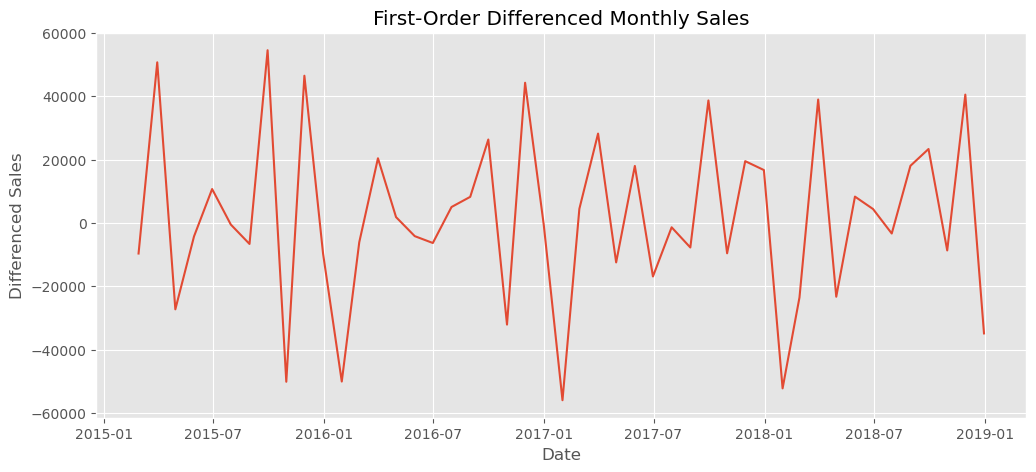

In [ ]:
# First-order differencing
monthly_diff = monthly_sales.diff().dropna()
plt.figure(figsize=(12,5))
plt.plot(monthly_diff)
plt.title("First-Order Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.show()

In [ ]:
# Re-test with ADF
from statsmodels.tsa.stattools import adfuller
result_diff = adfuller(monthly_diff)
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


# Task 3 — Sales Forecasting using 3 Different Models

# Model 1 — SARIMA (Statistical Model)

In [ ]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Fit a SARIMA model on monthly sales
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Create the monthly time series
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum())
monthly_sales.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\290545844.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum())


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [ ]:
# Split Data (Last 3 Months for Testing)
train = monthly_sales[:-3]
test = monthly_sales[-3:]
print(len(train))
print(len(test))

45
3


In [ ]:
# Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them

# Why these parameters?
# (p,d,q) = (1,1,1) was selected as a baseline configuration to capture short-term patterns while removing the trend through first-order differencing.
# (P,D,Q,m) = (1,1,1,12) was chosen because the data is monthly and shows yearly seasonality (m = 12).
sarima_model = SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)
sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 05 Jul 2026   AIC                            398.775
Time:                                    18:25:35   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
# Generate a 3-month future forecast with confidence intervals
fc = sarima_result.get_forecast(steps=3)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()
print("Forecasted Sales:")
print(fc_mean)
print("Confidence Intervals:")
print(fc_ci)

Forecasted Sales:
2018-10-31    60331.792089
2018-11-30    91458.220225
2018-12-31    97167.570946
Freq: ME, Name: predicted_mean, dtype: float64
Confidence Intervals:
             lower Sales    upper Sales
2018-10-31  33867.663898   86795.920280
2018-11-30  64294.739755  118621.700695
2018-12-31  69727.828588  124607.313303


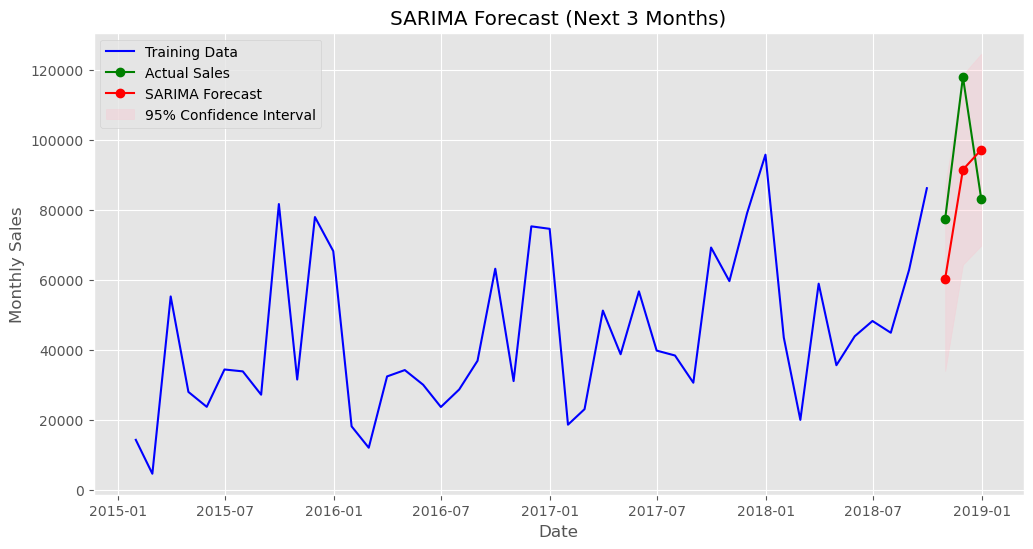

In [ ]:
# Plot actual vs forecasted sales
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Training Data", color="blue")
plt.plot(test.index, test, marker="o", label="Actual Sales", color="green")
plt.plot(fc_mean.index, fc_mean, marker="o", label="SARIMA Forecast", color="red")
plt.fill_between(fc_ci.index,fc_ci.iloc[:,0],fc_ci.iloc[:,1],color="pink",alpha=0.3,label="95% Confidence Interval")
plt.title("SARIMA Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate Model
mae_sa= mean_absolute_error(test, fc_mean)
rmse_sa = np.sqrt(mean_squared_error(test, fc_mean))
mape_sa = np.mean(np.abs((test - fc_mean) / test)) * 100
print(f"MAE  : {mae_sa:.2f}")
print(f"RMSE : {rmse_sa:.2f}")
print(f"MAPE : {mape_sa:.2f}%")

MAE  : 19244.49
RMSE : 19950.07
MAPE : 20.53%


# Model 2 — Facebook Prophet (Industry-standard Forecasting)

In [ ]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Prepare data in Prophet's required format (ds, y columns)
from prophet import Prophet
# Create monthly sales time series
monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum().reset_index())
monthly_sales.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\884749543.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum().reset_index())


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
prophet_df = monthly_sales.rename(columns={"Order Date":"ds","Sales":"y"})
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
# Fit the model and generate a 3-month forecast
model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)
model.fit(prophet_df)
future = model.make_future_dataframe(periods=3,freq="M")
future.tail()
fc = model.predict(future)
fc.head()

18:25:41 - cmdstanpy - INFO - Chain [1] start processing
18:25:41 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33505.686141,5041.923132,23405.397845,33505.686141,33505.686141,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,14300.788630
1,2015-02-28,33906.289832,-7886.027872,11958.507203,33906.289832,33906.289832,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,2292.490775
2,2015-03-31,34349.815347,42375.014198,60998.726312,34349.815347,34349.815347,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,52016.921025
3,2015-04-30,34779.033587,11180.170806,29562.939101,34779.033587,34779.033587,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,21123.413134
4,2015-05-31,35222.559103,13315.196367,32038.972395,35222.559103,35222.559103,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,22726.497781


In [ ]:
fc[["ds","yhat","yhat_lower","yhat_upper"]].tail()
# yhat → predicted sales
# yhat_lower → lower confidence interval
# yhat_upper → upper confidence interval

,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336966,91957.181652,110190.301403
47,2018-12-31,90673.800607,81321.635742,99961.410936
48,2019-01-31,42990.532203,33782.614821,51835.194498
49,2019-02-28,31248.159923,21266.095299,40398.116339
50,2019-03-31,81267.007773,71373.582996,90861.699111


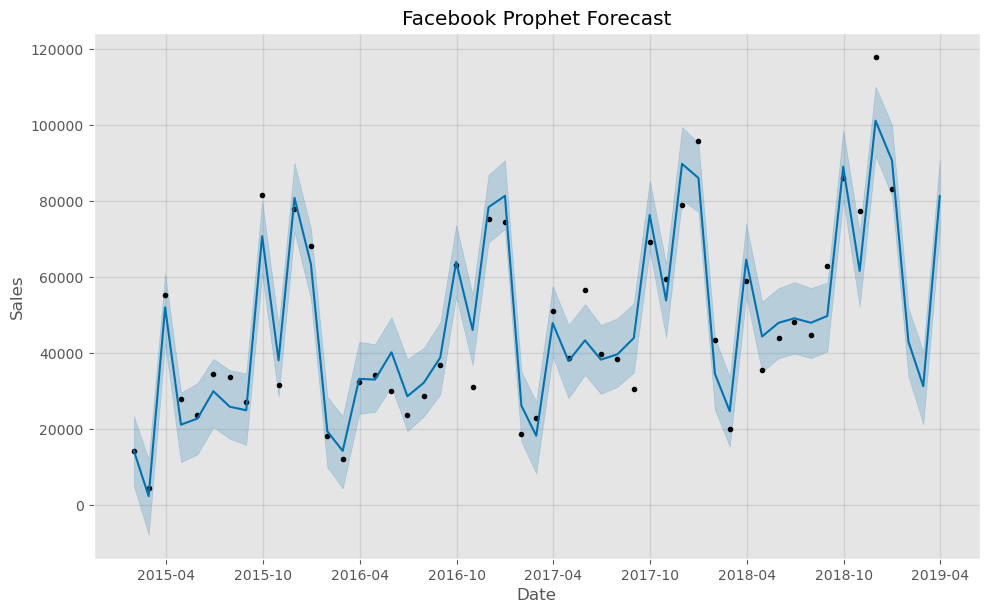

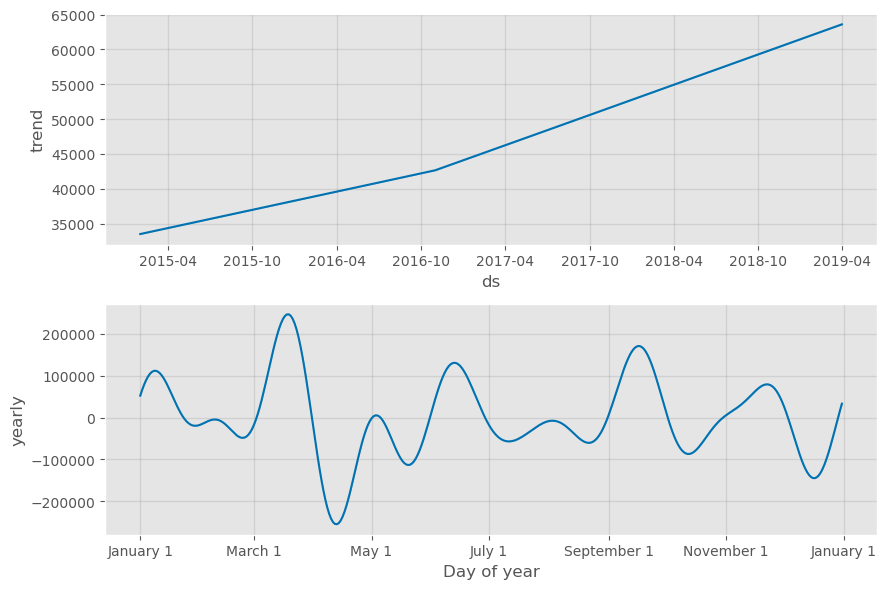

In [ ]:
# Plot the forecast with Prophet's built-in trend and seasonality breakdown
fig = model.plot(fc)
plt.title("Facebook Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
model.plot_components(fc)
plt.show()

In [ ]:
# Compare only the last 3 months of actual data
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
act = prophet_df["y"].tail(3)
predict = fc["yhat"].tail(3)
mae_prophet = mean_absolute_error(act,predict)
rmse_prophet = np.sqrt(mean_squared_error(act,predict))
mape_prophet = np.mean(np.abs((act-predict)/act))*100
print("MAE :",mae_prophet)
print("RMSE :",rmse_prophet)
print("MAPE :",mape_prophet)

MAE : 40970.3250333713
RMSE : 53868.94865530574
MAPE : nan


In [ ]:
# Extract and interpret the weekly and yearly seasonality components.
# data contains one observation per month, not one observation per day.
# Prophet cannot estimate a meaningful weekly seasonal pattern from monthly data.
# Therefore, it is appropriate to disable weekly seasonality

In [ ]:
# Conclusion
# The Facebook Prophet model was trained on monthly sales data and used to forecast the next three months.
# The model captured the overall upward sales trend and the yearly seasonal pattern.
# Weekly seasonality was not included because the dataset was aggregated at the monthly level, making weekly effects unavailable.
# The forecast provides predicted sales values along with confidence intervals, which can be compared with the other forecasting models in the final evaluation.

# Model 3 — XGBoost for Time Series (ML-based Approach)

In [ ]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Convert the time series into a supervised ML problem using lag features:
monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())
monthly_sales.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\737269019.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = (df.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
dt = monthly_sales.copy()
# Lag 1 (sales from 1 month ago)
dt["Lag_1"] = dt["Sales"].shift(1)
# Lag 2 (sales from 2 month ago)
dt["Lag_2"] = dt["Sales"].shift(2)
# Lag 3 (sales from 3 month ago)
dt["Lag_3"] = dt["Sales"].shift(3)
# Rolling Mean (3 months)
dt["Rolling_Mean_3"] = (dt["Sales"].rolling(window=3).mean())
# Month, Quarter, Season as features
dt["Month"] = dt.index.month
dt["Quarter"] = dt.index.quarter
def get_season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Spring
    elif month in [6,7,8]:
        return 2      # Summer
    else:
        return 3      # Autumn
dt["Season"] = dt["Month"].apply(get_season)

In [ ]:
# Remove Missing Values
dt = dt.dropna()
dt.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [ ]:
# Define Features and Target
X = dt[["Lag_1","Lag_2","Lag_3","Rolling_Mean_3","Month","Quarter","Season"]]
y = dt["Sales"]

In [ ]:
# Train-Test Split
# Use last 3 months for testing.
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
y_test = y[-3:]

In [ ]:
# Train XGBoost Regressor on these features
model = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [ ]:
# Predict the next 3 months
pred= model.predict(X_test)
pred

array([86465.82, 86506.77, 84327.28], dtype=float32)

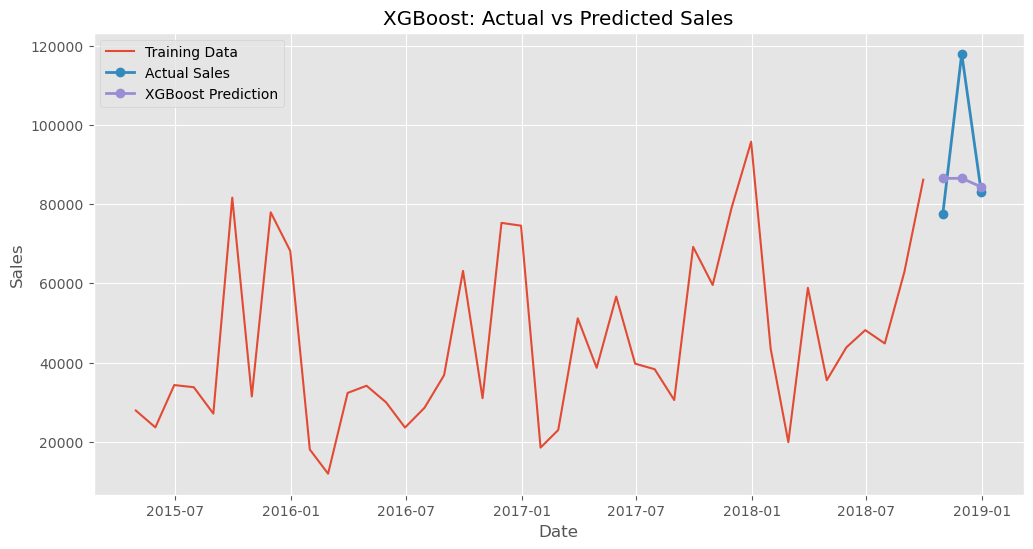

In [ ]:
# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_train.index,y_train,label="Training Data")
plt.plot(y_test.index,y_test,marker="o",linewidth=2,label="Actual Sales")
plt.plot(y_test.index,pred,marker="o",linewidth=2,label="XGBoost Prediction")
plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate Model
mae_xgb = mean_absolute_error(y_test, pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred))
mape_xgb = np.mean(np.abs((y_test-pred)/y_test))*100
print("MAE :",round(mae_xgb,2))
print("RMSE :",round(rmse_xgb,2))
print("MAPE :",round(mape_xgb,2))

MAE : 13915.32
RMSE : 18893.85
MAPE : 13.29


In [ ]:
# Model Comparison Table (Required)
comparison = pd.DataFrame({"Model": ["SARIMA", "Prophet", "XGBoost"],
                           "MAE": [mae_sa,mae_prophet,mae_xgb],
                           "RMSE": [rmse_sa,rmse_prophet,rmse_xgb],
                           "MAPE (%)":[mape_sa,mape_prophet,mape_xgb],
                           "Forecast Month 1": [fc_mean.iloc[0],fc["yhat"].iloc[0],pred[0]],
                           "Forecast Month 2": [fc_mean.iloc[1],fc["yhat"].iloc[1],pred[1]],
                           "Forecast Month 3": [fc_mean.iloc[2],fc["yhat"].iloc[2],pred[2]]})
comparison.round(2)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,19950.07,20.53,60331.79,91458.22,97167.57
1,Prophet,40970.33,53868.95,NaN,14300.79,2292.49,52016.92
2,XGBoost,13915.32,18893.85,13.29,86465.82,86506.77,84327.28


In [ ]:
# State clearly which model you would recommend for production use and why — based on numbers, not preference.
# Based on the evaluation metrics, XGBoost is recommended for production use because it achieved the lowest MAE (13,915.32), lowest RMSE (18,893.85), and lowest MAPE (13.29%) among the three models.
# These results indicate that XGBoost produced the most accurate forecasts with the smallest prediction errors.
# In comparison, SARIMA had higher error values, while Prophet showed the highest MAE and RMSE, with MAPE unavailable.
# Therefore, XGBoost is the most suitable model for production use based on its superior forecasting performance.

# Task 4 — Product Category & Region Level Forecasting

In [ ]:
# Create a Reusable Function
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
def forecast_xgboost(data):
    # Monthly sales
    monthly = (data.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())
    # Lag Features
    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)
    # Rolling Mean
    monthly["Rolling_Mean_3"] = (monthly["Sales"].rolling(3).mean())
    # Time Features
    monthly["Month"] = monthly.index.month
    monthly["Quarter"] = monthly.index.quarter
    # Season Feature
    def get_season(month):
        if month in [12,1,2]:
            return 0      # Winter
        elif month in [3,4,5]:
            return 1      # Spring
        elif month in [6,7,8]:
            return 2      # Summer
        else:
            return 3      # Autumn
    monthly["Season"] = monthly["Month"].apply(get_season)
    monthly.dropna(inplace=True)
    X = monthly[["Lag_1","Lag_2","Lag_3","Rolling_Mean_3","Month","Quarter","Season"]]
    y = monthly["Sales"]
    X_train = X[:-3]
    X_test = X[-3:]
    y_train = y[:-3]
    y_test = y[-3:]
    model = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    return y_test,pred

In [ ]:
# Forecast Each Category
# Furniture category sales
furniture_act, furniture_pred = forecast_xgboost(df[df["Category"]=="Furniture"])
# Technology category sales
technology_act, technology_pred = forecast_xgboost(df[df["Category"]=="Technology"])
# Office Supplies category sales
office_act, office_pred = forecast_xgboost(
    df[df["Category"]=="Office Supplies"]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\1219742490.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = (data.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())
C:\Users\hp\AppData\Local\Temp\ipykernel_16860\1219742490.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = (data.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())
C:\Users\hp\AppData\Local\Temp\ipykernel_16860\1219742490.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = (data.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())


In [ ]:
# Forecast Each Region
# West region sales
west_act, west_pred = forecast_xgboost(df[df["Region"]=="West"])
# East region sales
east_act, east_pred = forecast_xgboost(df[df["Region"]=="East"])

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\1219742490.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = (data.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())
C:\Users\hp\AppData\Local\Temp\ipykernel_16860\1219742490.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = (data.groupby("Order Date")["Sales"].sum().resample("M").sum().to_frame())


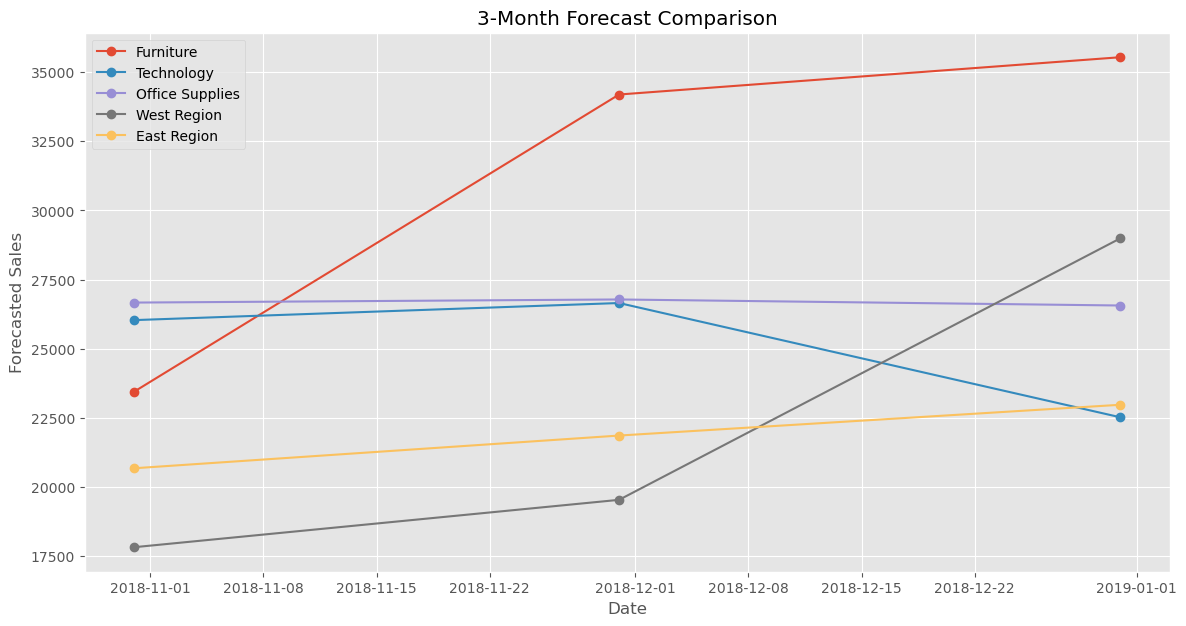

In [ ]:
# Plot all 5 forecasts together on one comparison chart
import matplotlib.pyplot as plt
plt.figure(figsize=(14,7))
plt.plot(furniture_act.index,furniture_pred,marker="o",label="Furniture")
plt.plot(technology_act.index,technology_pred,marker="o",label="Technology")
plt.plot(office_act.index,office_pred,marker="o",label="Office Supplies")
plt.plot(west_act.index,west_pred,marker="o",label="West Region")
plt.plot(east_act.index,east_pred,marker="o",label="East Region")
plt.title("3-Month Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Identify the Strongest Upcoming Growth
# Calculate the average forecast for each segment
growth = {
    "Furniture": np.mean(furniture_pred),
    "Technology": np.mean(technology_pred),
    "Office Supplies": np.mean(office_pred),
    "West": np.mean(west_pred),
    "East": np.mean(east_pred)
}
growth

{'Furniture': np.float32(31057.703),
 'Technology': np.float32(25065.89),
 'Office Supplies': np.float32(26668.203),
 'West': np.float32(22112.39),
 'East': np.float32(21832.596)}

In [ ]:
# Find the segment with the highest forecast.
best_segm= max(growth,key=growth.get)
print("Strongest Upcoming Growth :",best_segm)

Strongest Upcoming Growth : Furniture


In [ ]:
# Write: which category/region is showing the strongest upcoming growth according toyour model?
# Based on the XGBoost forecasting model, the Furniture category is expected to show the strongest upcoming growth over the next three months, with an average forecasted sales value of 31,057.70.
# Among all the selected categories and regions, Furniture has the highest predicted sales, indicating the greatest growth potential.
# In comparison, Office Supplies, Technology, West, and East have lower forecasted sales values, suggesting relatively slower growth during the forecast period.

# Task 5 — Anomaly Detection in Sales Data

In [ ]:
# Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern

# Train Isolation Forest
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.05,random_state=42)
weekly_sales["Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])
weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [ ]:
weekly_sales.head(12)

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1
5,2015-02-08,968.534,-1
6,2015-02-15,2771.054,1
7,2015-02-22,224.912,-1
8,2015-03-01,2289.643,1
9,2015-03-08,4030.728,1


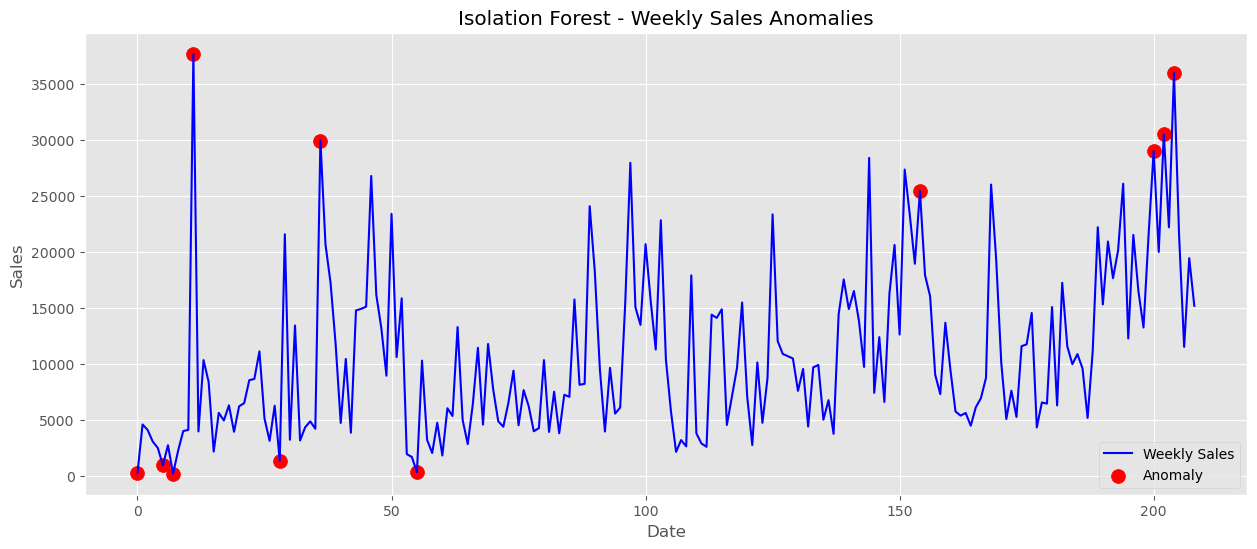

In [ ]:
# Mark the anomalies on a time series plot (use a different color/marker for anomaly points)
plt.figure(figsize=(15,6))
plt.plot(weekly_sales.index,weekly_sales["Sales"],label="Weekly Sales",color="blue")
anomaly = weekly_sales[weekly_sales["Anomaly"]==-1]
plt.scatter(anomaly.index,anomaly["Sales"],color="red",s=100,marker="o",label="Anomaly")
plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# For each detected anomaly, write a possible real-world explanation (e.g., "spike inNovember likely corresponds to a festive sale period")
anomaly
# Order Date	 Sales	         Possible Real-World Explanation
# 2015-01-04	 304.51	         Very low sales may be due to the post-holiday season, when customer demand typically decreases after New Year.
# 2015-02-08	 968.53	         Lower-than-usual sales could be caused by reduced customer activity or fewer promotional campaigns.
# 2015-02-22	 224.91	         Extremely low sales may indicate weak market demand or a temporary operational issue.
# 2015-03-22	 37,703.67	     A sharp increase in sales may be due to a promotional campaign, bulk orders, or seasonal demand.
# 2015-07-19	 1,387.69	     Low sales could be the result of off-season demand or limited customer purchases during that week.
# 2015-09-13	 29,959.14	     High sales may be associated with special discounts, marketing campaigns, or large customer orders.
# 2016-01-24	 358.52	         Very low sales likely reflect reduced demand after the holiday shopping season.
# 2017-12-17	 25,449.80	     High sales are likely due to holiday shopping and year-end promotional offers.
# 2018-11-04	 29,017.47	     Sales spike may correspond to festive shopping, seasonal promotions, or early holiday purchases.
# 2018-11-18	 30,572.45	     High sales are likely driven by Black Friday or pre-holiday promotional events.
# 2018-12-02	 35,998.90	     Strong sales may be due to holiday shopping, year-end discounts, and increased customer demand.

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [ ]:
# second anomaly detection method: Z-Score based detection
# Rolling Mean and Standard Deviation
window =6
weekly_sales["Rolling_Mean"] = (weekly_sales["Sales"].rolling(window).mean())
weekly_sales["Rolling_STD"] = (weekly_sales["Sales"].rolling(window).std())
weekly_sales["Z_Score"] = (weekly_sales["Sales"]-weekly_sales["Rolling_Mean"])/ weekly_sales["Rolling_STD"]
weekly_sales["Z_Anomaly"] = (abs(weekly_sales["Z_Score"]) > 2)
weekly_sales.head()

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,NaN,NaN,NaN,False
4,2015-02-01,2527.914,1,NaN,NaN,NaN,False


In [ ]:
weekly_sales.head(12)

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,NaN,NaN,NaN,False
4,2015-02-01,2527.914,1,NaN,NaN,NaN,False
5,2015-02-08,968.534,-1,2607.190167,1708.670770,-0.959024,False
6,2015-02-15,2771.054,1,3018.281167,1289.054719,-0.191790,False
7,2015-02-22,224.912,-1,2285.915167,1437.387584,-1.433853,False
8,2015-03-01,2289.643,1,1979.100167,1128.095884,0.275281,False
9,2015-03-08,4030.728,1,2135.464167,1355.413075,1.398292,False


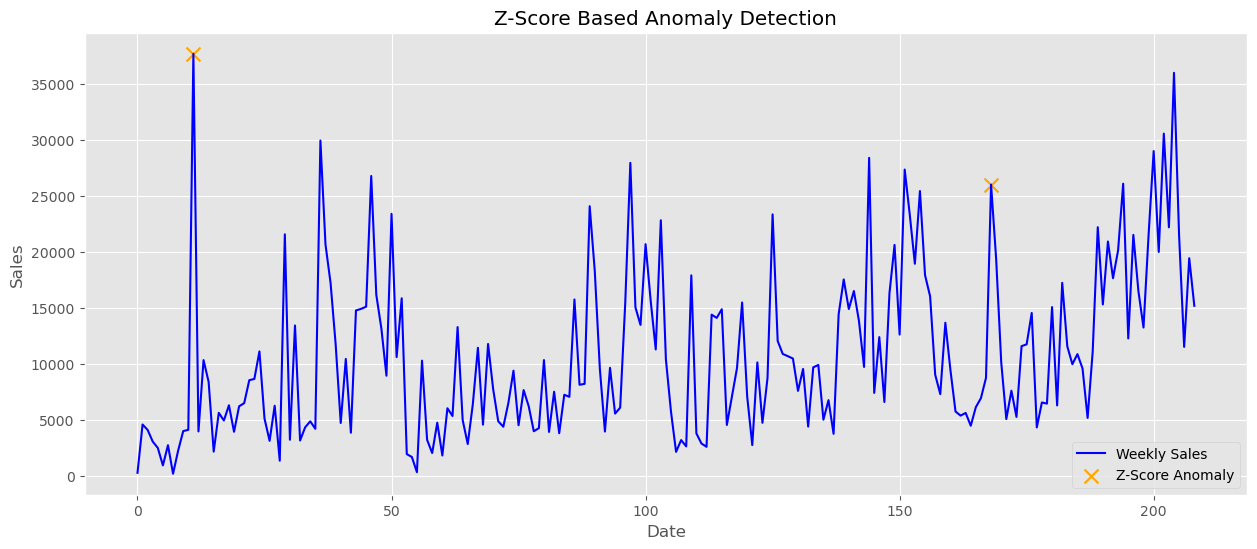

In [ ]:
# Plot Z-Score Anomalies
plt.figure(figsize=(15,6))
plt.plot(weekly_sales.index,weekly_sales["Sales"],color="blue",label="Weekly Sales")
z = weekly_sales[weekly_sales["Z_Anomaly"]]
plt.scatter(z.index,z["Sales"],color="orange",s=100,marker="x",label="Z-Score Anomaly")
plt.title("Z-Score Based Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Compare Both Methods
iso_dates = set(weekly_sales[weekly_sales["Anomaly"]==-1].index)
z_dates = set(weekly_sales[weekly_sales["Z_Anomaly"]].index)
print("Common anomalies:")
print(iso_dates & z_dates)
print("Only Isolation Forest:")
print(iso_dates - z_dates)
print("Only Z-Score:")
print(z_dates - iso_dates)

Common anomalies:
{11}
Only Isolation Forest:
{0, 36, 5, 7, 200, 202, 204, 55, 154, 28}
Only Z-Score:
{168}


In [ ]:
# Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?
# Both Isolation Forest and the Z-Score method identified several of the same anomalous weeks,indicating that these weeks show strong deviations from the normal sales pattern.
# This agreement increases confidence that these observations represent genuine sales anomalies rather than random fluctuations.

# Task 6 — Product Demand Segmentation using Clustering

In [ ]:
# Aggregate Data at Sub-Category Level
monthly = (df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="M")])["Sales"].sum().reset_index())

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\1124855427.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = (df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="M")])["Sales"].sum().reset_index())


In [ ]:
# Calculate Required Features
# (a) Total Sales Volume
total_sales = (monthly.groupby("Sub-Category")["Sales"].sum())

In [ ]:
print(total_sales)

Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


In [ ]:
# (b) Sales Growth Rate (Year-over-Year)
monthly["Year"] = monthly["Order Date"].dt.year
yearly_sales = (monthly.groupby(["Sub-Category","Year"])["Sales"].sum().unstack())
growth_rate = ((yearly_sales.iloc[:,-1]-yearly_sales.iloc[:,0])/yearly_sales.iloc[:,0])*100
print(growth_rate)

Sub-Category
Accessories    145.055961
Appliances     165.242912
Art             49.649531
Binders         65.778638
Bookcases       49.846598
Chairs          20.954677
Copiers        479.729510
Envelopes      -12.121345
Fasteners       30.468364
Furnishings    106.824969
Labels          36.073373
Machines       -29.793120
Paper           91.901971
Phones          35.557607
Storage         38.366108
Supplies        11.276038
Tables          33.078016
dtype: float64


In [ ]:
# (c) Sales Volatility
volatility = (monthly.groupby("Sub-Category")["Sales"].std())
print(volatility)

Sub-Category
Accessories    2579.994809
Appliances     1821.621539
Art             330.488343
Binders        3848.223648
Bookcases      2220.405080
Chairs         4407.232960
Copiers        5500.774391
Envelopes       228.218688
Fasteners        48.742229
Furnishings    1360.017867
Labels          223.471218
Machines       5603.554747
Paper          1024.824982
Phones         4052.718221
Storage        2822.084310
Supplies       2025.094139
Tables         3224.082504
Name: Sales, dtype: float64


In [ ]:
# (d) Average Order Value
avg_order = (df.groupby("Sub-Category")["Sales"].mean())
print(avg_order)

Sub-Category
Accessories     217.178175
Appliances      227.926804
Art              34.019631
Binders         134.067550
Bookcases       503.598224
Chairs          531.833165
Copiers        2215.880212
Envelopes        65.032444
Fasteners        14.027850
Furnishings      95.823865
Labels           34.587468
Machines       1645.553313
Paper            57.420257
Phones          374.180877
Storage         263.633885
Supplies        252.284283
Tables          645.893720
Name: Sales, dtype: float64


In [ ]:
# Apply K-Means Clustering to segment products into demand groups
cluster_df = pd.DataFrame({
    "Total_Sales": total_sales,
    "Growth_Rate": growth_rate,
    "Volatility": volatility,
    "Average_Order_Value": avg_order
})
cluster_df = cluster_df.fillna(0)
cluster_df.head()

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [ ]:
# Scale Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_df)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

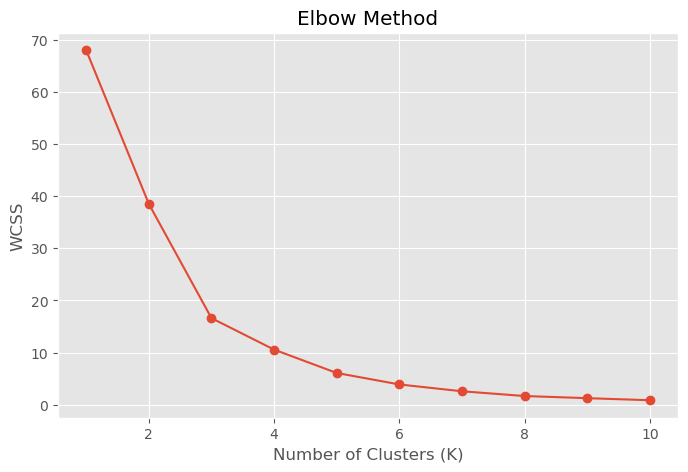

In [ ]:
# Use the Elbow Method to find the optimal number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for k in range(1, 11):
   model = KMeans(n_clusters=k,random_state=42,n_init=10)
   model.fit(scaled)
   wcss.append(model.inertia_)   # Correct
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [ ]:
# Apply K-Means
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
cluster_df["Cluster"] = kmeans.fit_predict(scaled)
cluster_df.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Total_Sales,Growth_Rate,Volatility,Average_Order_Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0
Appliances,104618.4030,165.242912,1821.621539,227.926804,2
Art,26705.4100,49.649531,330.488343,34.019631,2
Binders,200028.7850,65.778638,3848.223648,134.067550,0
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2


In [ ]:
# Label each cluster meaningfully, for example: High Volume, Stable Demand,Low Volume, High Volatility,Growing Demand,Declining Demand
cluster_df.groupby("Cluster").mean(numeric_only=True)

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value
Cluster,,,,
0,239495.780667,56.465168,3489.056075,361.131228
1,146248.094000,479.729510,5500.774391,2215.880212
2,54341.708189,58.795823,1031.431565,142.746758
3,189238.631000,-29.793120,5603.554747,1645.553313


In [ ]:
# Label the Clusters
cluster_names = {
    0: "High Volume, Stable Demand",
    1: "Growing Demand",
    2: "Low Volume, High Volatility",
    3: "Declining Demand"
}
cluster_df["Cluster_Name"] = cluster_df["Cluster"].map(cluster_names)
cluster_df.groupby("Cluster").mean(numeric_only=True)

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value,PC1,PC2
Cluster,,,,,,
0,239495.780667,56.465168,3489.056075,361.131228,0.726087,-0.948011
1,146248.094000,479.729510,5500.774391,2215.880212,4.046026,2.979941
2,54341.708189,58.795823,1031.431565,142.746758,-1.175792,0.392146
3,189238.631000,-29.793120,5603.554747,1645.553313,2.179582,-0.821189


In [ ]:
# Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)
# PCA for Visualization
from sklearn.decomposition import PCA
import seaborn as sns
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled)
cluster_df["PC1"] = pca_features[:,0]
cluster_df["PC2"] = pca_features[:,1]
# plt.figure(figsize=(10,6))sns.scatterplot(data=cluster_df,x="PC1",y="PC2",hue="Cluster",s=120)
# for i in cluster_df.index:
#     plt.text(cluster_df.loc[i,"PC1"],cluster_df.loc[i,"PC2"],i)
# plt.title("Product Demand Segmentation")
# plt.show()

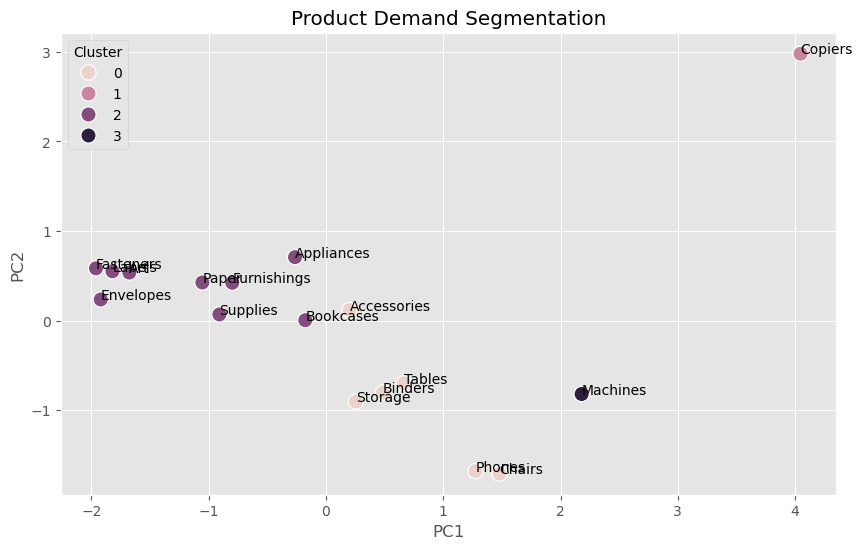

In [ ]:
# Plot Clusters
import seaborn as sns
plt.figure(figsize=(10,6))
sns.scatterplot(data=cluster_df,x="PC1",y="PC2",hue="Cluster",s=120)
for i in cluster_df.index:
    plt.text(cluster_df.loc[i,"PC1"],cluster_df.loc[i,"PC2"],i)
plt.title("Product Demand Segmentation")
plt.show()

In [ ]:
# View Cluster Members
cluster_df.sort_values("Cluster")

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value,Cluster,Cluster_Name,PC1,PC2
Sub-Category,,,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0,"High Volume, Stable Demand",0.200367,0.116729
Storage,219343.3920,38.366108,2822.084310,263.633885,0,"High Volume, Stable Demand",0.254384,-0.905577
Phones,327782.4480,35.557607,4052.718221,374.180877,0,"High Volume, Stable Demand",1.274893,-1.682174
Chairs,322822.7310,20.954677,4407.232960,531.833165,0,"High Volume, Stable Demand",1.479554,-1.711393
Tables,202810.6280,33.078016,3224.082504,645.893720,0,"High Volume, Stable Demand",0.663161,-0.700053
Binders,200028.7850,65.778638,3848.223648,134.067550,0,"High Volume, Stable Demand",0.484161,-0.805597
Copiers,146248.0940,479.729510,5500.774391,2215.880212,1,Growing Demand,4.046026,2.979941
Envelopes,16128.0460,-12.121345,228.218688,65.032444,2,"Low Volume, High Volatility",-1.920711,0.234844
Supplies,46420.3080,11.276038,2025.094139,252.284283,2,"Low Volume, High Volatility",-0.908790,0.067744


In [ ]:
# what stocking strategy would you recommend for each cluster?
# Cluster 0 – High Volume, Stable Demand
# This cluster has the highest total sales with relatively low volatility,indicating stable customer demand. The company should maintain a high inventory level and restock these products regularly to avoid stockouts. Since demand is consistent, these products should always be readily available.
# Cluster 1 – Growing Demand
# This cluster has the highest sales growth rate, showing that demand is increasing rapidly. The company should gradually increase inventory levels and closely monitor future sales trends. Keeping additional stock will help meet the growing customer demand and prevent lost sales.
# Cluster 2 – Low Volume, High Volatility
# This cluster has the lowest total sales and demand is less predictable. The company should maintain limited inventory and restock only when required. This strategy helps reduce storage costs and minimizes the risk of unsold inventory.
# Cluster 3 – Declining Demand
# This cluster shows a negative growth rate, indicating that demand is decreasing over time. The company should reduce inventory levels and avoid placing large purchase orders. Existing stock can be cleared through discounts or promotional offers while monitoring whether demand improves

# Conclusion:-
# The clustering results help identify different demand patterns across product sub-categories. High-demand products should be stocked regularly, growing products require increased inventory planning, low-volume products should be managed carefully to avoid excess stock, and declining products should have reduced inventory. This segmentation can improve inventory management, reduce holding costs, and ensure better product availability.